In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from itertools import groupby
from operator import itemgetter
from scipy.stats import spearmanr, pearsonr
import matplotlib as mpl

In [2]:
# Load the data
data = pd.read_csv("Kanyapella.csv")

data['avg_temp']=(pd.to_numeric(data['max_temp'])+pd.to_numeric(data['min_temp']))/2
data['Date'] = pd.to_datetime(data['YYYY-MM-DD'], format="%d/%m/%Y")

In [3]:
Et = pd.to_numeric(data['et_morton_actual'])

# Get rainfall column
Rain = pd.to_numeric(data['daily_rain'])

# Initialize H
H = [0]

# Calculate H using the formula iteratively
for i in range(1, len(data)):
    H.append(max(0, H[i-1] + Rain[i-1] - Et[i-1]))

# Add result to DataFrame
data['H'] = H

In [4]:
T_values_adjusted = data['avg_temp'][243+365:]
R_values_adjusted = pd.to_numeric(data['daily_rain'], errors='coerce')[243+365:]
H_values_adjusted = data['H'][243+365:]
Et_values_adjusted = Et[243+365:]

# Relevant date range
dates_adjusted = np.arange(np.datetime64('1979-09-01'), np.datetime64('1985-05-01'))

In [5]:
mpl.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 10,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,

    # Axis lines
    "axes.linewidth": 0.5,

    # Tick thickness
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,

    # Tick length (optional but helpful)
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # Line plots
    "lines.linewidth": 1,

    # Fonts
    "font.family": "Arial",

    # PDF export
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

In [6]:
letters = ['A', 'B', 'C', 'D']

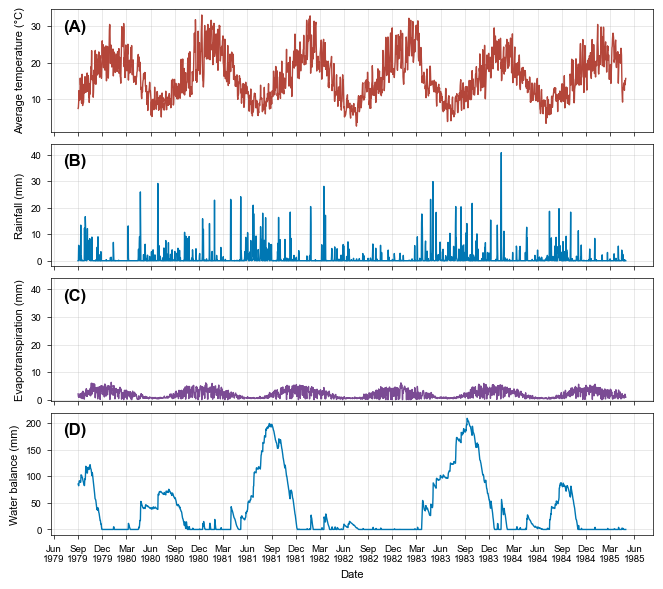

In [7]:
### Plot setup
fig_width = 170 / 25.4
fig_height = 150 / 25.4

fig, axes = plt.subplots(4, 1, figsize=(fig_width, fig_height), sharex=True)
ax1, ax2, ax3, ax4 = axes

# Subplot for Temperature values
ax1 = plt.subplot(4, 1, 1)
ax1.plot(dates_adjusted[:2069], T_values_adjusted[:2069], color='#B4463A')
ax1.set_ylabel('Average temperature (°C)')
ax1.grid(True, linewidth = 0.4, alpha = 0.5)
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[12, 3, 6, 9]))

# Subplot for Rainfall values
ax2 = plt.subplot(4, 1, 2)
ax2.plot(dates_adjusted[:2069], R_values_adjusted[:2069], color='#0077B3')
ax2.set_ylabel('Rainfall (mm)')
ax2.grid(True, linewidth = 0.4, alpha = 0.5)
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[12, 3, 6, 9]))
ax2.set_ylim(top=44)

# Subplot for Evapotranspiration values
ax3 = plt.subplot(4, 1, 3)
ax3.plot(dates_adjusted[:2069], Et_values_adjusted[:2069], color='#7B4B94')
ax3.set_ylabel('Evapotranspiration (mm)')
ax3.grid(True, linewidth = 0.4, alpha = 0.5)
ax3.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[12, 3, 6, 9]))
ax3.set_ylim(top=44)

# Subplot for water balance values
ax4 = plt.subplot(4, 1, 4)
ax4.plot(dates_adjusted[:2069], H_values_adjusted[:2069], color='#0077B3')
ax4.set_xlabel('Date')
ax4.set_ylabel('Water balance (mm)')
ax4.grid(True, linewidth = 0.4, alpha = 0.5)
# Set major ticks to every 3 months — Dec, Mar, Jun, Sep
ax4.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[12, 3, 6, 9]))
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

for ax in [ax1, ax2, ax3, ax4]:
    ax.tick_params(axis='both')
    
for ax, letter in zip(axes, letters):
    ax.tick_params(axis='both')
    ax.text(
        0.02, 0.92,
        f'({letter})',
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        va='top',
        ha='left'
    )

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.97,
    bottom=0.08,
    hspace=0.1
)

# Show the plot
plt.show()